<a href="https://colab.research.google.com/github/lovey7768/neural-sketch-diffusion/blob/main/neural_sketch_diffusion.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

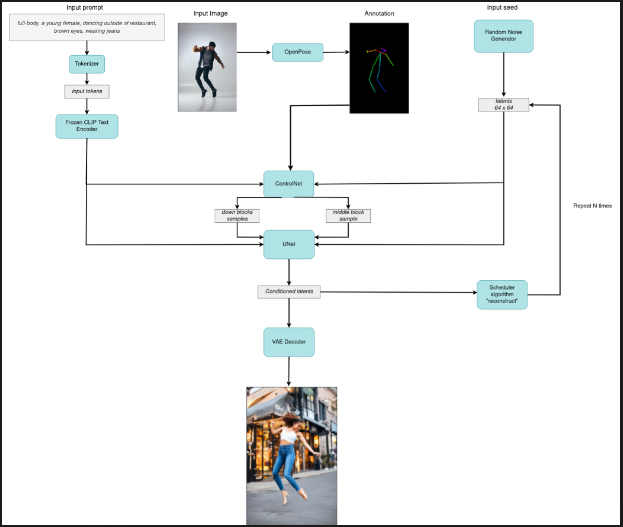

**User Sketch / Photo ──► OpenCV Canny Detector ──► ControlNet Guidance ──► UNet Denoising Loop ──► Rendered Image**

# Install Dependencies

In [5]:
!pip install -q diffusers transformers accelerate controlnet_aux gradio opencv-python torch

# Build the Neural Diffusion Engine

In [4]:
import torch
import cv2
import numpy as np
from PIL import Image
from diffusers import StableDiffusionControlNetPipeline, ControlNetModel, UniPCMultistepScheduler
# 1.load the lightweight Canny ControlNet adapter
controlnet=ControlNetModel.from_pretrained(
    'lllyasviel/sd-controlnet-canny',
    torch_dtype=torch.float16
)

# 2.Assemble the stable diffusion pipline
pipe= StableDiffusionControlNetPipeline.from_pretrained(
    "runwayml/stable-diffusion-v1-5",
    controlnet=controlnet,
    torch_dtype=torch.float16
).to("cuda")

# 3.optimize scheduler for fast inference steps(20 steps instead of 50)
pipe.scheduler=UniPCMultistepScheduler.from_config(pipe.scheduler.config)

# 4. Enable xformers memory attention optimization to fit free T4 VRAM
pipe.enable_attention_slicing()

def generate_art(input_image, prompt,negative_prompt, low_threshold=100, high_threshold=200):
  print("generate_art started") # Debug print
  if input_image is None:
    print("Input image is None, returning None, None") # Debug print
    return None, None

  try:
    # Convert input PIL image to numpy array for edge extraction
    img_np= np.array(input_image)
    print(f"img_np shape: {img_np.shape}, dtype: {img_np.dtype}") # Debug print

    # process edges via canny detector matrix
    canny_edges = cv2.Canny(img_np, low_threshold, high_threshold)
    print(f"canny_edges shape: {canny_edges.shape}, dtype: {canny_edges.dtype}") # Debug print
    canny_3channel = np.stack([canny_edges]* 3, axis=-1)
    detected_map= Image.fromarray(canny_3channel)
    print("detected_map created") # Debug print

    # Run reverse diffusion process guided by structral edge conditions
    output= pipe(
        prompt=prompt,
        negative_prompt=negative_prompt,
        image=detected_map,
        num_inference_steps=20,
        guidance_scale=7.5
    ).images[0]
    print("pipe executed successfully") # Debug print
    return detected_map, output
  except Exception as e:
    print(f"An error occurred in generate_art: {e}") # Debug print
    import traceback
    traceback.print_exc() # Print full traceback
    return None, None # Return two Nones on error to match expected output for Gradio

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_validators.py:205: UserWarning: The `local_dir_use_symlinks` argument is deprecated and ignored in `hf_hub_download`. Downloading to a local directory does not use symlinks anymore.
  warnings.warn(


Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/396 [00:00<?, ?it/s]

# Launch the free interactive Gradio Web App

In [6]:
import gradio as gr

# build an intuitive dual-canvas inerface

interface=gr.Interface(
    fn=generate_art,
    inputs=[
        gr.Image(type="pil", label="Upload Sketch or Draw Photo"),
        gr.Textbox(label='Prompt', value="a detailed cinematic digital painting of futuristic sports car, 8k, photorealistic"),
        gr.Textbox(label="Negative Prompt",value="blurry, low quality, distorted, bad proportion"),
        gr.Slider(10,250, value=100, label="Canny Low threshold"),
        gr.Slider(10,250, value=200, label="Canny high Threshold")
    ],
    outputs=[
        gr.Image(label="Extracted Structural Edge Map"),
        gr.Image(label="Generated Neural Output")
    ],
    title=" Neural Sketch-to-Art diffusion Engine",
    description="Guided Image Generation powered by ControlNet,pytorch, and Stable Diffuision v1.5."
)
# setting share=True creates a free public URl accessible from anywhere
interface.launch(share=True, debug=True)

Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: https://aa9581447f138af7be.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


generate_art started
img_np shape: (527, 747, 3), dtype: uint8
canny_edges shape: (527, 747), dtype: uint8
detected_map created


  0%|          | 0/20 [00:00<?, ?it/s]

pipe executed successfully
Using existing dataset file at: .gradio/flagged/dataset1.csv
Keyboard interruption in main thread... closing server.
Killing tunnel 127.0.0.1:7860 <> https://aa9581447f138af7be.gradio.live
